# Waveguide box

Simple elongated box waveguide mesh with two waveports.

Generates a rectangular waveguide (elongated box) where:
- The two end faces are labeled "waveport_1" and "waveport_2"
- The four lateral surfaces are labeled "metal"

Our goal is to measure the s parameters.

In [1]:
import gmsh
import math
import os
import sys
import json
from pathlib import Path

from palacetoolkit.viz import run_with_scrollable_output, view_mesh
from palacetoolkit.geometry import extract_tag, xmin, xmax, ymin, ymax, zmin, zmax
from palacetoolkit.mesh import refine_near_surfaces

### Parameters
- filename : Output mesh filename
- width : width of the waveguide in meters
- height : height of the waveguide in meters
- length : length of the waveguide in meters

In [2]:
filename="waveguide_box.msh"

# Default dimensions of the waveguide box (wr-90 standard)
width=22.86e-3     
height=10.16e-3    
length=100e-3      

### Initialization of the model

In [3]:
gmsh.initialize()
gmsh.model.add("waveguide_box")
kernel = gmsh.model.occ

### Geometry definition

In [4]:
# Create an elongated box centered at the origin

# addBox(x, y, z, dx, dy, dz) — (x,y,z) is the corner
box = kernel.addBox(
    -width / 2, -height / 2, 0,
    width, height, length,
)

kernel.synchronize()

### Identifying Geometric Entities and Domains

In [5]:
# Identify surfaces by their bounding box positions
all_surfaces = gmsh.model.getEntities(2)

waveport_1_tags = []  # face at z = 0
waveport_2_tags = []  # face at z = length
metal_tags = []       # the four lateral faces

eps = 1e-6

for dimtag in all_surfaces:

    if abs(zmin(dimtag) - 0.0) < eps and abs(zmax(dimtag) - 0.0) < eps:
        waveport_1_tags.append(dimtag)
    elif abs(zmin(dimtag) - length) < eps and abs(zmax(dimtag) - length) < eps:
        waveport_2_tags.append(dimtag)
    else:
        metal_tags.append(dimtag)

assert len(waveport_1_tags) == 1, f"Expected 1 waveport_1 face, found {len(waveport_1_tags)}"
assert len(waveport_2_tags) == 1, f"Expected 1 waveport_2 face, found {len(waveport_2_tags)}"
assert len(metal_tags) == 4, f"Expected 4 metal faces, found {len(metal_tags)}"

### Defining Physical Groups
To prepare the geometry for export to Palace, we must define "Physical Groups." These groups serve as labels that the solver uses to identify boundaries (surfaces) and domains (volumes) for applying physics settings, such as excitation ports or material properties.

In [6]:
# Physical groups (these become boundary attributes in Palace)
pg_waveport_1 = gmsh.model.addPhysicalGroup(2, [x[1] for x in waveport_1_tags], name="waveport_1")
pg_waveport_2 = gmsh.model.addPhysicalGroup(2, [x[1] for x in waveport_2_tags], name="waveport_2")
pg_metal = gmsh.model.addPhysicalGroup(2, [x[1] for x in metal_tags], name="metal")

# Volume physical group 
all_volumes = gmsh.model.getEntities(3)
vol_tags = [tag for _, tag in all_volumes]
pg_volume = gmsh.model.addPhysicalGroup(3, vol_tags, name="waveguide_volume")

# Map physical group names to their tags for later use.
pg_map = {
    "waveport_1": pg_waveport_1,
    "waveport_2": pg_waveport_2,
    "metal": pg_metal,
    "volume": pg_volume
}

### Mesh Generation and Export
Next, we define the mesh resolution based on our operating frequency (10 GHz) and generate the final mesh for the Palace solver.

- Refinement: We ensure higher mesh density near the waveports to capture electromagnetic behavior accurately.
- Settings: We use the Frontal-Delaunay algorithm and set the mesh to first-order elements.
- Export: The mesh is saved in the Gmsh 2.2 ASCII format, which is required for compatibility with Palace.

  ppw_near=20  ppw_far=10
  SizeMax=0.0030  transition=0.0075
  global: 8 curves, SizeMin=0.0015


-------------------------------------------------------
Version       : 4.15.2
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260324
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


Loading mesh file: waveguide_box.msh
Groups to render transparent: ['air_none', 'air_plastic_enclosure']

Mesh loaded successfully with 2 cell blocks
Found 2528 triangles total
Physical group tags in mesh: {1: 'waveport_1', 2: 'waveport_2', 3: 'metal'}


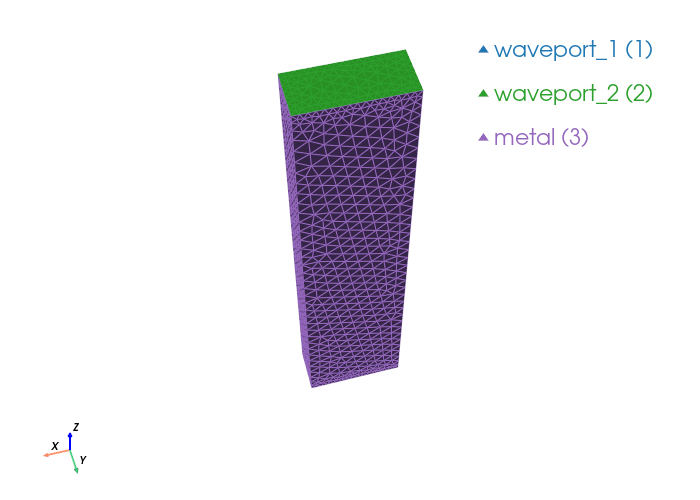

In [7]:
def _generate_waveguide_box_mesh():
    freq = 10e9  # 10 GHz
    c = 3e8     # speed of light in vacuum
    wavelength = c / freq

    refine_near_surfaces(waveport_1_tags + waveport_2_tags, ppw_far=10, ppw_near=20, wavelength=wavelength)

    # Meshing
    gmsh.option.setNumber("Mesh.Algorithm", 6)    # Frontal-Delaunay for 2D
    gmsh.option.setNumber("Mesh.Algorithm3D", 2)  # Frontal-Delaunay for 3D

    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)

    # Output in Gmsh 2.2 ASCII format (Palace compatible)
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.option.setNumber("Mesh.Binary", 0)

    script_dir = os.getcwd()
    output_path = os.path.join(script_dir, filename)
    gmsh.write(output_path)

run_with_scrollable_output(_generate_waveguide_box_mesh, title="Waveguide box mesh generation", max_lines=10)

if "-nopopup" not in sys.argv:
    gmsh.fltk.run()

gmsh.finalize()
view_mesh(filename)

### Write a Palace JSON config for a simple hollow waveguide.
- output_file: destination JSON path.
- freq_min:    start frequency [GHz].
- freq_max:    end frequency [GHz].
- freq_step:   frequency step [GHz].

In [8]:
output_file: str = "waveguide_box.json"
freq_min: float = 6.0
freq_max: float = 15.0
freq_step: float = 0.5

output_stem = Path(output_file).stem

config = {
    "Problem": {
        "Type": "Driven",
        "Verbose": 2,
        "Output": f"/work/postpro/{output_stem}",
    },
    "Model": {
        "Mesh": f"/work/{filename}",
        "L0": 1.0,
        "Refinement": {},
    },
    "Domains": {
        "Materials": [
            {
                "Attributes": [pg_map["volume"]],
                "Permeability": 1.0,
                "Permittivity": 1.0,
                "LossTan": 0.0,
            }
        ],
    },
    "Boundaries": {
        "PEC": {
            "Attributes": [pg_map["metal"]],
        },
        "WavePort": [
            {
                "Index": 1,
                "Attributes": [pg_map["waveport_1"]],
                "Mode": 1,
                "Offset": 0.0,
                "Excitation": True,
            },
            {
                "Index": 2,
                "Attributes": [pg_map["waveport_2"]],
                "Mode": 1,
                "Offset": 0.0,
            },
        ],
    },
    "Solver": {
        "Order": 2,
        "Device": "CPU",
        "Driven": {
            "MinFreq": freq_min,
            "MaxFreq": freq_max,
            "FreqStep": freq_step,
            "SaveStep": 1,
            "AdaptiveTol": 0.001,
        },
        "Linear": {
            "Type": "Default",
            "KSPType": "GMRES",
            "Tol": 1e-8,
            "MaxIts": 200,
        },
    },
}

script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file)
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Palace config written to {config_path}")

Palace config written to /home/martin/Desktop/PalaceToolkit/docs/examples/waveguide_box.json
